## Phenotypic changes after drug treatment

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import rcParams

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3               
sc.logging.print_version_and_date()

# making sure plots & clusters are reproducible
np.random.seed(42)

## custom functions
#import sc_toolbox as sct

Running Scanpy 1.10.3, on 2025-04-09 07:44.


In [2]:
## path variables
adata_dir = '/mnt/smb/Niklas/GLPG_data_temp/250109_GLPG_annotated_d21_subset.h5ad'
data_dir = '/home/niklas/projects/GLPG_drug_perturbations/01_data/'
out_dir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig3/'

In [3]:
## plotting variables
sc.settings.figdir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig3/'
sc.set_figure_params(vector_friendly = True)
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['pdf.fonttype'] = 42

In [4]:
## load anndata object
adata = sc.read(adata_dir)

In [5]:
adata

AnnData object with n_obs × n_vars = 230989 × 24500
    obs: 'identifier', 'time_point', 'n_counts', 'preprocessing_cluster', 'size_factors', 'S_score', 'G2M_score', 'phase', 'treatment_time', 'treatment', 'sample_name', 'condition', 'percent_mito', 'cluster_03', 'doublet_scores', 'n_genes', 'louvain_1', 'louvain_2', 'cell_type', 'group', 'ChromiumBatch', 'LibraryPrepBatch', 'SeqBatch', 'ashcroft_score', 'body_weight_d0', 'body_weight_d1', 'body_weight_d2', 'body_weight_d3', 'body_weight_d4', 'body_weight_d5', 'body_weight_d6', 'body_weight_d7', 'body_weight_d8', 'body_weight_d9', 'body_weight_d10', 'body_weight_d11', 'body_weight_d12', 'body_weight_d13', 'body_weight_d14', 'body_weight_d15', 'body_weight_d16', 'body_weight_d17', 'body_weight_d18', 'body_weight_d19', 'body_weight_d20', 'body_weight_d21', 'body_weight_min', 'body_weight_max', 'delta_max_body_weight', 'delta_body_weight_d7_10', 'delta_body_weight_d14_d21'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispe

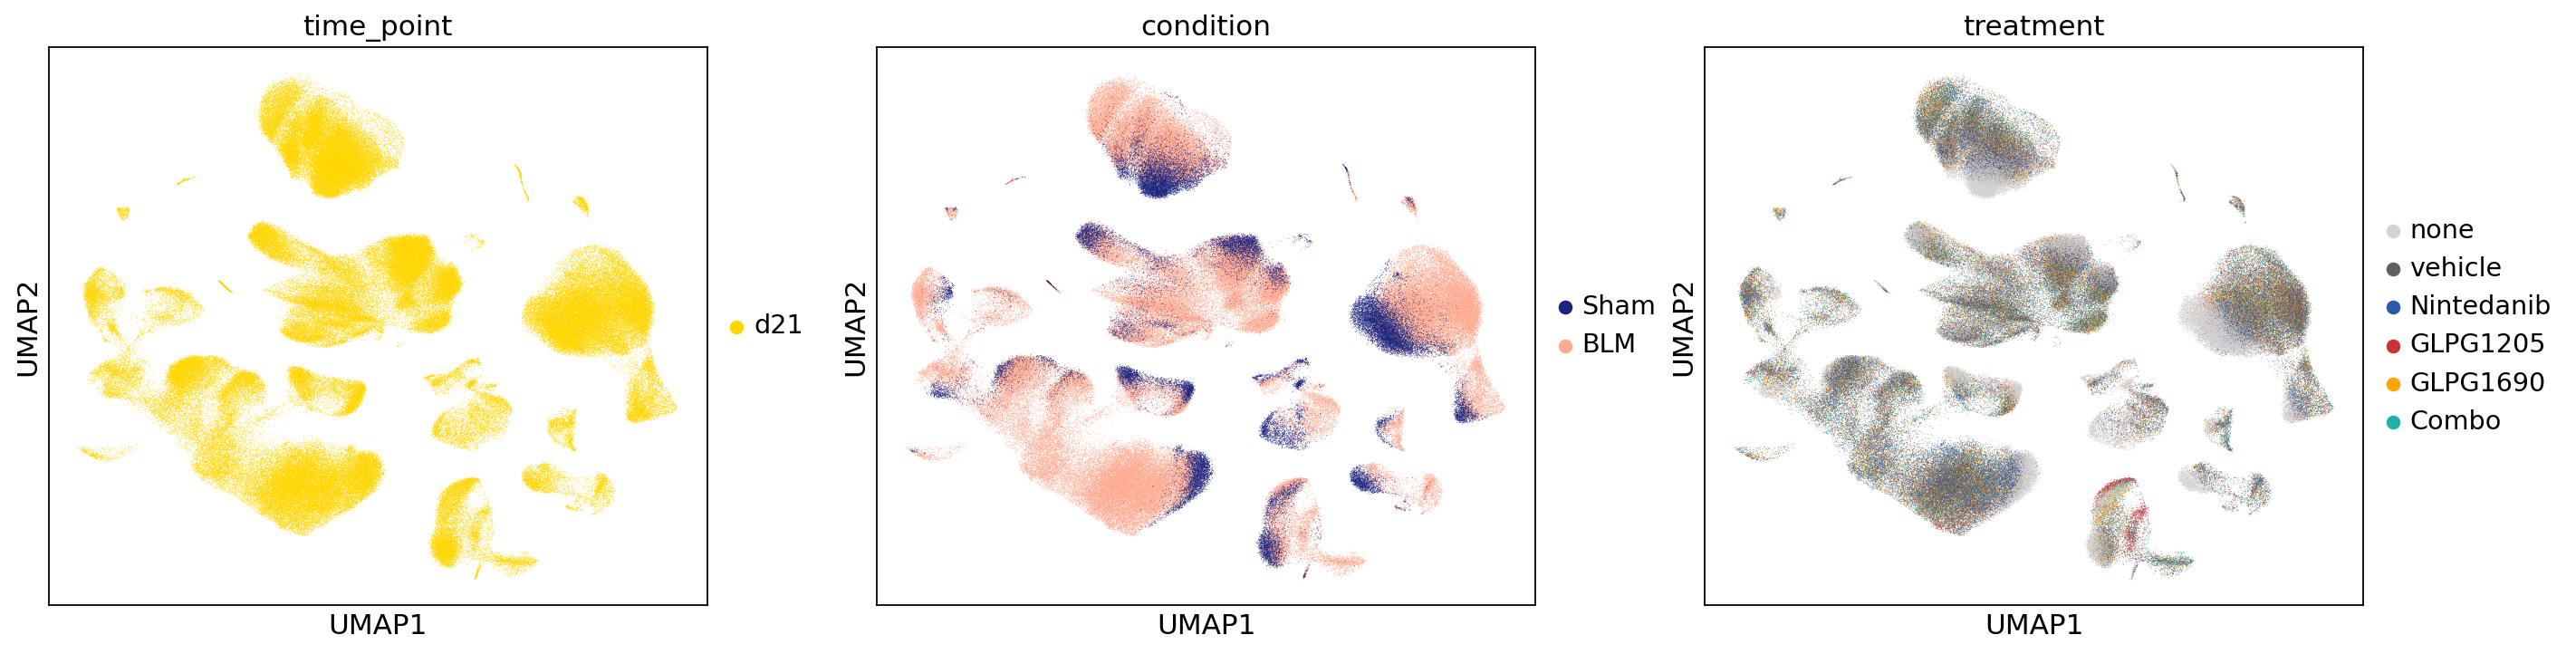

In [6]:
sc.pl.umap(adata, color = ['time_point','condition','treatment'])

### Function to calculate the percentage of k-nearest neighbors from healthy vs. fibrotic reference mice

In [7]:
## PCA
sc.pp.pca(adata, use_highly_variable = True)
## kNN
sc.pp.neighbors(adata, n_pcs = 50, n_neighbors = 50)

computing PCA
    with n_comps=50


/home/niklas/miniconda3/envs/ccc_env/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


    finished (0:00:18)
computing neighbors
    using 'X_pca' with n_pcs = 50


/home/niklas/miniconda3/envs/ccc_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:01:31)


In [8]:
import scipy.sparse as sp

In [9]:
def calc_phenotype_score(adata,
                         condition,
                         reference_conditions = ('healthy','disease'),
                         n_neighbors=50,
                         distances_key='distances',
                         connectivities_key='connectivities'):
    
    ## ensure necessary keys exist in adata
    if connectivities_key not in adata.obsp:
        raise KeyError('kNN connectivities are missing in adata.obsp.')
    
    ## get kNN graph connectivities
    connectivities = adata.obsp[connectivities_key]
    ## get condition annotations
    condition_annotations = adata.obs[condition]

    ## ensure connectivities is sparse
    if not sp.issparse(connectivities):
        raise TypeError('Connectivities must be a sparse matrix.')

    ## initialize an empty array for phenotype scores
    phenotype_scores = np.zeros(connectivities.shape[0])

    ## encode condition annotations as binary (0 for disease, 1 for healthy)
    condition_binary = condition_annotations.isin([reference_conditions[0]]).astype(int).values

    ## iterate over rows to find top n_neighbors for each cell
    for i in range(connectivities.shape[0]):
        
        ## extract row as sparse array
        row = connectivities.getrow(i).toarray().flatten()

        ## find indices of top n_neighbors by sorting only largest n_neighbors
        top_indices = np.argpartition(-row, n_neighbors)[:n_neighbors]
        ## sort top neighbors by weight
        #top_indices = top_indices[np.argsort(-row[top_indices])] 

        ## compute the phenotype score for the current cell
        #weights = row[top_indices]
        #scores = condition_binary[top_indices] * weights
        #phenotype_scores[i] = np.sum(scores) / np.sum(weights) * 100 if np.sum(weights) > 0 else 0
        scores = condition_binary[top_indices]
        phenotype_scores[i] = np.sum(scores) / len(top_indices) * 100 if len(top_indices) > 0 else 0

    ## store the scores in adata.obs
    adata.obs['phenotype_score'] = phenotype_scores
    return adata

In [10]:
adata = calc_phenotype_score(adata, n_neighbors = 100, condition = 'treatment', reference_conditions=('none','vehicle'))

### Calculate average score per treatment and cell state

In [11]:
def calculate_average_scores(adata,
                             cell_type_col,
                             treatment_col):
    
    ## ensure necessary columns exist
    if 'phenotype_score' not in adata.obs or cell_type_col not in adata.obs or treatment_col not in adata.obs:
        raise KeyError('Required columns are missing in adata.obs.')
    
    ## subset to relevant treatment
    query = adata[-adata.obs[treatment_col].isin(['none'])]
    
    ## group by cell type and treatment, and calculate the average phenotype score
    grouped = query.obs.groupby([cell_type_col, treatment_col])['phenotype_score'].mean().reset_index()

    ## rename columns for clarity
    grouped.columns = ['cell_type', 'treatment', 'average_phenotype_score']

    return grouped

In [12]:
## get average score for cell type of interest
cell_types_of_interest = ['T reg cells',
                 'Lipo/Myofibroblast Transition',
                 'Proliferating AM',
                 'Cthrc1+ Myofibroblasts',
                 'pDC',
                 'Krt8+ ADI',
                 'Vwa1+/Col15a1+ ectopic capillary EC',
                 'M2 Macrophages',
                 'Transitional Monocytes',
                 'Eosinophils',
                 'Proliferating T cells']

subset = adata[adata.obs['cell_type'].isin(cell_types_of_interest)]

In [13]:
## compute average scores per cell type
avg_scores = calculate_average_scores(subset, cell_type_col='cell_type', treatment_col='treatment')

/tmp/ipykernel_2100552/4019568093.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = query.obs.groupby([cell_type_col, treatment_col])['phenotype_score'].mean().reset_index()


In [14]:
## show results
avg_scores.head()

,cell_type,treatment,average_phenotype_score
0,Krt8+ ADI,vehicle,14.721311
1,Krt8+ ADI,Nintedanib,15.299320
2,Krt8+ ADI,GLPG1205,16.813333
3,Krt8+ ADI,GLPG1690,16.247059
4,Krt8+ ADI,Combo,15.945455


In [15]:
## calculate the ratio in reference to Bleo
avg_scores['average_phenotype_score_ratio'] = avg_scores.groupby('cell_type').apply(
    lambda group: group['average_phenotype_score'] / group.loc[group['treatment'] == 'vehicle', 'average_phenotype_score'].values[0]
).reset_index(drop=True)

/tmp/ipykernel_2100552/2729526107.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_scores['average_phenotype_score_ratio'] = avg_scores.groupby('cell_type').apply(
/tmp/ipykernel_2100552/2729526107.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  avg_scores['average_phenotype_score_ratio'] = avg_scores.groupby('cell_type').apply(


In [16]:
avg_scores.head()

,cell_type,treatment,average_phenotype_score,average_phenotype_score_ratio
0,Krt8+ ADI,vehicle,14.721311,1.000000
1,Krt8+ ADI,Nintedanib,15.299320,1.039263
2,Krt8+ ADI,GLPG1205,16.813333,1.142108
3,Krt8+ ADI,GLPG1690,16.247059,1.103642
4,Krt8+ ADI,Combo,15.945455,1.083154


### Visualize results

In [17]:
cell_type_order = ['Proliferating AM',
                   'Transitional Monocytes',
                   'M2 Macrophages',
                   'Lipo/Myofibroblast Transition',
                   'Cthrc1+ Myofibroblasts',
                   'Vwa1+/Col15a1+ ectopic capillary EC',
                   'Eosinophils',
                   'Proliferating T cells',
                   'pDC',
                   'T reg cells',
                   'Krt8+ ADI'
                  ]

In [18]:
## reorder dataframe
avg_scores = pd.concat([avg_scores[avg_scores['cell_type'] == ref] for ref in cell_type_order])
avg_scores['cell_type'] = pd.Categorical(avg_scores['cell_type'], categories=cell_type_order, ordered=True)
avg_scores.head()

,cell_type,treatment,average_phenotype_score,average_phenotype_score_ratio
30,Proliferating AM,vehicle,15.768802,1.000000
31,Proliferating AM,Nintedanib,20.976471,1.330251
32,Proliferating AM,GLPG1205,17.330612,1.099044
33,Proliferating AM,GLPG1690,18.398649,1.166775
34,Proliferating AM,Combo,16.035639,1.016922


In [19]:
## color palette for plotting
treatment_colors = ['#606060','#2E59A8','#FFA500','#C93333','#20B2AA']

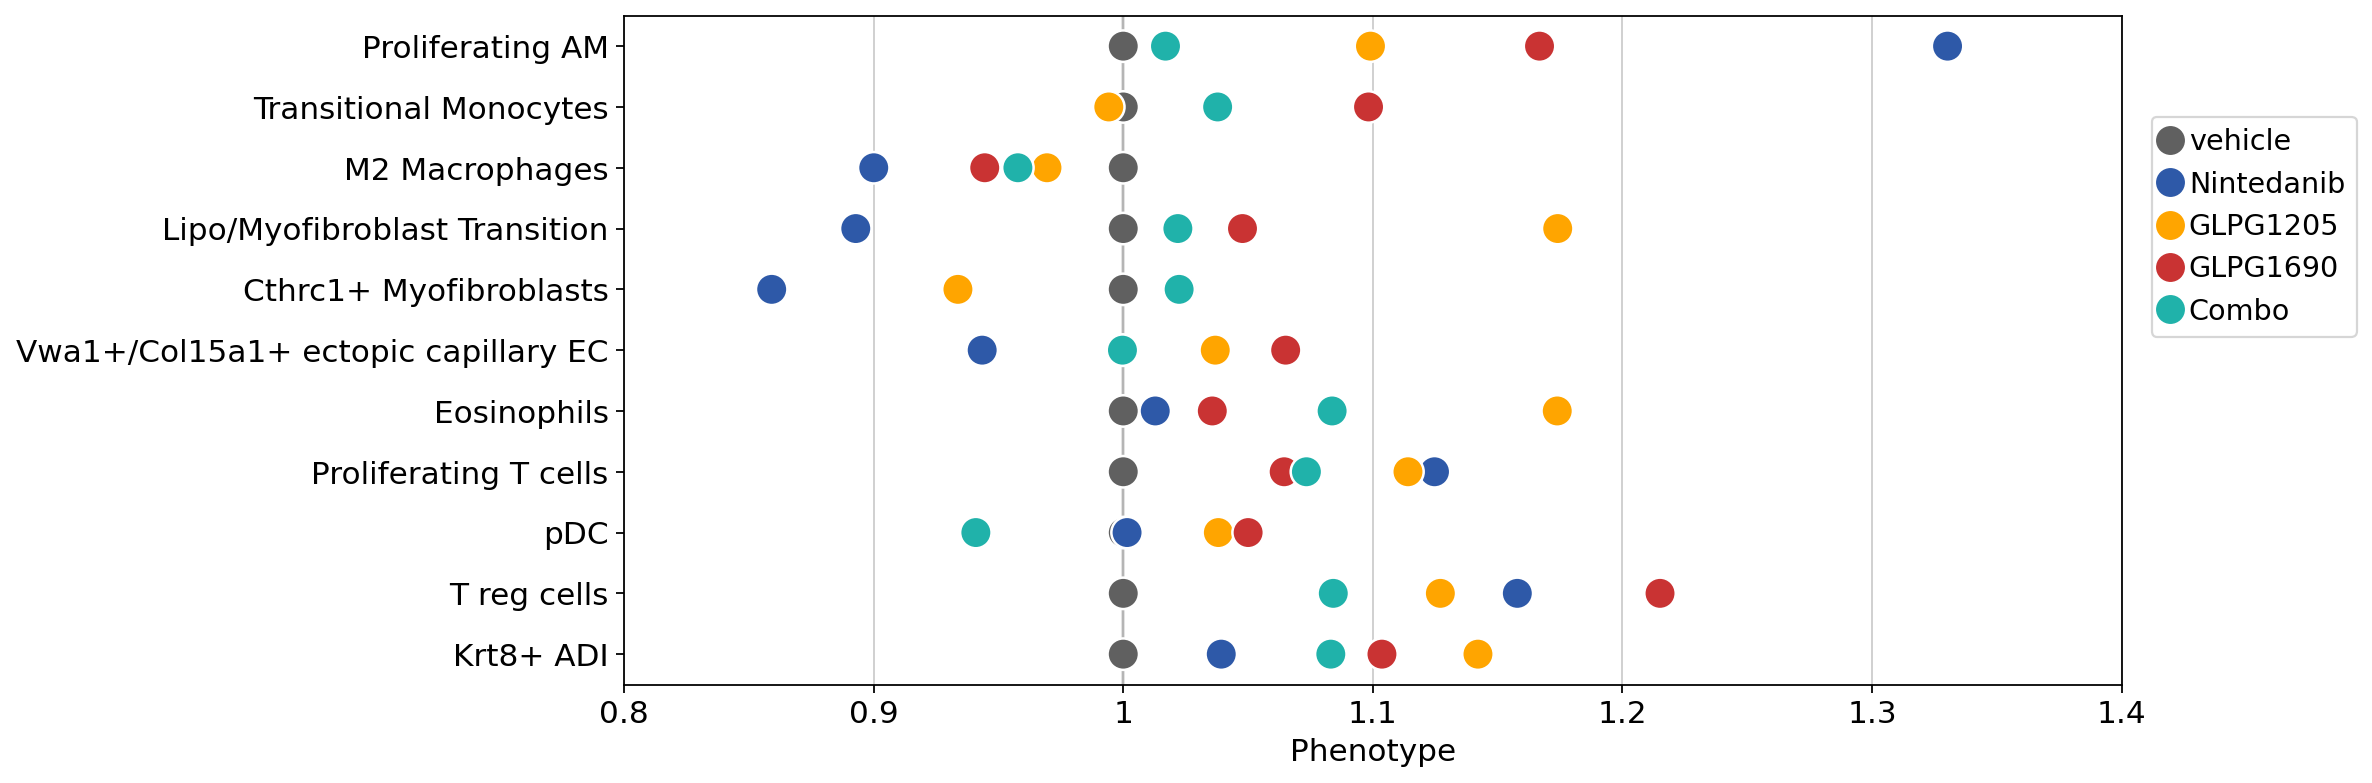

In [21]:
plt.figure(figsize=(12, len(cell_types_of_interest) * 0.5))
sb.scatterplot(data = avg_scores,
               x = 'average_phenotype_score_ratio',
               y = 'cell_type',
               hue = 'treatment',
               palette = treatment_colors,
               s=200,
               zorder=3)

## set logarithmic scale for the x-axis
#plt.xscale('log')

## no horizontal lines
plt.grid(axis='y', visible=False)

## regularly spaced vertical grid lines
x_ticks = [0.8,0.9,1,1.1,1.2,1.3,1.4]  ## key tick positions
plt.gca().set_xticks(x_ticks)
plt.gca().set_xticklabels(x_ticks)  ## ensure tick labels are displayed

## black vertical reference line
plt.axvline(x=1, color='black', linestyle='-', linewidth=1, zorder=-1)

## labels
plt.ylabel('')
plt.xlabel('Phenotype')
plt.legend(loc=(1.02, 0.52))

## save figure
plt.savefig(out_dir + 'phenotype_score_kNN_top.pdf', format='pdf', bbox_inches='tight')

## show figure
plt.show()